Project root: D:\WorkSpace\python\chan.py
2024/01/12 09:30:buy price = 45997.0
2024/01/26 17:15:sell price = 41753.7, profit rate = -9.23%
2024/02/13 13:45:buy price = 49543.2
2024/02/14 08:15:sell price = 49774.0, profit rate = 0.47%
2024/03/12 15:15:buy price = 72109.2
2024/03/18 05:45:sell price = 68746.5, profit rate = -4.66%
2024/03/19 14:45:buy price = 62928.4
2024/03/26 07:45:sell price = 70535.0, profit rate = 12.09%
2024/04/03 00:45:buy price = 65433.9
2024/04/07 15:30:sell price = 69605.8, profit rate = 6.38%
2024/04/09 01:30:buy price = 71354.4
2024/04/21 03:15:sell price = 65126.8, profit rate = -8.73%
2024/04/24 19:15:buy price = 64379.0
2024/05/03 21:00:sell price = 62744.7, profit rate = -2.54%
2024/05/14 02:30:buy price = 62574.8
2024/05/17 15:45:sell price = 67170.0, profit rate = 7.34%
2024/05/24 08:30:buy price = 67111.3
2024/05/25 11:30:sell price = 69419.4, profit rate = 3.44%
2024/05/28 19:00:buy price = 68269.8
2024/06/05 15:45:sell price = 71625.1, profit rate =

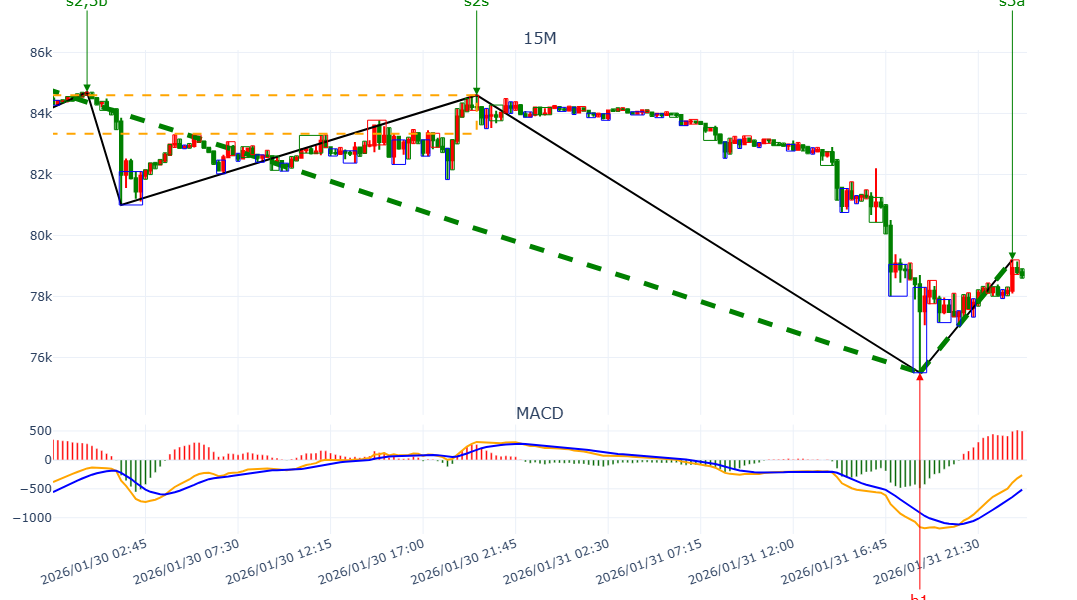

FileNotFoundError: [Errno 2] No such file or directory: 'result\\test.html'

In [1]:
# %load test1.py

# ===== 必须放在最前面 =====
import sys
import os

project_root = os.path.abspath("..")  # Debug 的上一级

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)
"""
示例策略：仅用于展示如何向 `CChan` 外部喂入 K 线并触发缠论计算。
策略逻辑：当检测到底分型且为买点时开仓，遇到顶分型且为卖点时平仓。
仅作演示回测用途，不作为交易建议。
"""

from Chan import CChan
from ChanConfig import CChanConfig
from Common.CEnum import AUTYPE, BSP_TYPE, DATA_SRC, FX_TYPE, KL_TYPE
from DataAPI.csvAPI import CSV_API
from Plot import get_plot_driver

if __name__ == "__main__":
    # === 参数设置 ===
    code = "BTCUSDT"  # 标的代码
    begin_time = "2024-01-01"  # 起始时间（用于回测）
    end_time = "2026-02-04"  # 结束时间，None 表示直到最新
    data_src_type = DATA_SRC.CSV  # 数据来源类型
    lv_list = [KL_TYPE.K_15M]  # 使用的级别列表（这里只用日线）

    # 简洁配置：只保留示例需要的关键项
    config = CChanConfig({
        "trigger_step": True,
        "divergence_rate": 0.8,
        "min_zs_cnt": 1,
    })

    # 绘图开关：按需开启或关闭各类子图
    plot_config = {
        "plot_kline": True,
        "plot_kline_combine": True,
        "plot_bi": True,
        "plot_seg": True,
        "plot_eigen": False,
        "plot_zs": True,
        "plot_macd": True,
        "plot_mean": False,
        "plot_channel": False,
        "plot_bsp": True,
        "plot_extrainfo": False,
        "plot_demark": False,
        "plot_marker": False,
        "plot_rsi": False,
        "plot_kdj": False,
    }

    # 绘图参数：局部绘制参数和图像范围
    plot_para = {
        "seg": {},
        "bi": {},
        "figure": {"x_range": 200},
        "marker": {},
    }

    # 初始化缠论对象（部分参数在外部喂入场景中可不依赖）
    chan = CChan(
        code=code,
        begin_time=begin_time,
        end_time=end_time,
        data_src=data_src_type,
        lv_list=lv_list,
        config=config,
        autype=AUTYPE.QFQ,
    )

    # 初始化并创建数据源
    CSV_API.do_init()
    data_src = CSV_API(code, k_type=KL_TYPE.K_15M, begin_date=begin_time, end_date=end_time, autype=AUTYPE.QFQ)

    # 策略状态变量
    is_hold = False  # 是否持仓
    last_buy_price = None  # 记录最后一次买入价格

    # 主循环：按单根 K 线喂入缠论计算并检查买卖点
    for klu in data_src.get_kl_data():  # 遍历源数据中的每根 K 线
        chan.trigger_load({KL_TYPE.K_15M: [klu]})  # 将新 K 线推入 CChan

        # 获取最新的买卖点列表（内部根据缠论计算得出）
        bsp_list = chan.get_latest_bsp()
        if not bsp_list:
            continue

        last_bsp = bsp_list[0]
        # 只关注 T1/T1P 类型的买卖点（示例策略聚焦一类）
        if BSP_TYPE.T1 not in last_bsp.type and BSP_TYPE.T1P not in last_bsp.type:
            continue

        cur_lv_chan = chan[0]  # 取当前级别的缠论结构
        # 确保买卖点对应的是刚才计算出的分型（索引匹配）
        if last_bsp.klu.klc.idx != cur_lv_chan[-2].idx:
            continue

        # 开仓条件：前一个分型为底分型且买点标志且当前未持仓
        if cur_lv_chan[-2].fx == FX_TYPE.BOTTOM and last_bsp.is_buy and not is_hold:
            last_buy_price = cur_lv_chan[-1][-1].close
            print(f'{cur_lv_chan[-1][-1].time}:buy price = {last_buy_price}')
            is_hold = True

        # 平仓条件：前一个分型为顶分型且卖点标志且当前持仓
        elif cur_lv_chan[-2].fx == FX_TYPE.TOP and not last_bsp.is_buy and is_hold:
            sell_price = cur_lv_chan[-1][-1].close
            print(f'{cur_lv_chan[-1][-1].time}:sell price = {sell_price}, profit rate = {(sell_price-last_buy_price)/last_buy_price*100:.2f}%')
            is_hold = False

    # 关闭数据源
    CSV_API.do_close()

    # 使用 plotly 引擎绘图
    CPlotDriver = get_plot_driver("plotly")
    plot_driver = CPlotDriver(chan, plot_config=plot_config, plot_para=plot_para)
    plot_driver.show()
    plot_driver.save2img("./result/test.html")